<a href="https://colab.research.google.com/github/kanan9971/Credit_card_Fraud_system/blob/main/Fraud_detection_program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection with Logistic Regression (Payments Mini-Project)

**Goal:** Build a simple fraud detection model for credit card transactions
using machine learning, and understand how this maps to real-world payments
risk at a bank.

**Motivation (payments context):**
- Card and digital payments are a core business for banks.
- Fraud is rare but causes direct financial loss (chargebacks, write-offs)
  and damages customer trust.
- Banks run real-time fraud models during authorization to decide whether
  to approve, decline, or challenge a transaction.
- This notebook is a small-scale version of such a fraud-scoring system.

In [3]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML toolkit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## Dataset Description
I will be using the **Credit Card Fraud Detection** dataset from Kaggle
(ULB - Université Libre de Bruxelles):

- Kaggle link:
  https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- It contains credit card transactions made by European cardholders
  in September 2013 (2 days of data).[web:20]
- There are 284,807 transactions, with 492 labeled as fraud, making
  this a **highly imbalanced** dataset.[web:20]
- Most features (`V1`–`V28`) are the result of a PCA transformation, done
  to protect confidential details.[web:20]
- `Time` indicates seconds elapsed between each transaction and the first
  transaction in the dataset.
- `Amount` is the transaction amount.
- `Class` is the target label: 1 = fraud, 0 = non-fraud.[web:20]

This is realistic for payments because:
- Fraud is very rare compared to legitimate transactions.
- Feature engineering/transformations are common in bank models.
- We focus on detecting rare, high-impact events.

In [4]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

Saving creditcard.csv to creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

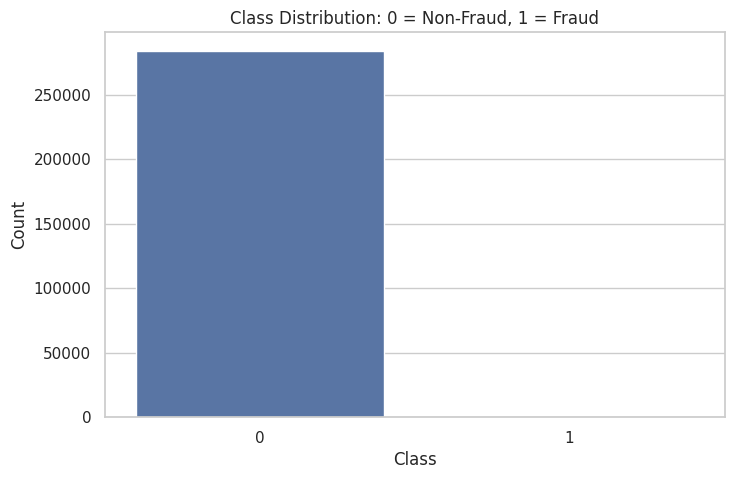

In [5]:
df.info()

# Quick stats
df.describe().T.head()

# Class distribution
class_counts = df['Class'].value_counts()
print(class_counts)
print("\nClass distribution (percentage):")
print(class_counts / len(df) * 100)

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution: 0 = Non-Fraud, 1 = Fraud")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Class Imbalance (Finance Perspective)

We observe that:

- The vast majority of transactions are labeled **0 (non-fraud)**.
- Only a very small fraction are labeled **1 (fraud)** (roughly 0.17%).[web:20]

This mirrors real-world card portfolios:

- Most customers transact legitimately.
- Fraud is rare but costly: each fraudulent transaction can mean a full loss
  for the issuer/acquirer and operational costs for investigations.

Implications for modeling:

- A naive model that always predicts "non-fraud" would achieve very high
  accuracy but provide no value.
- We must focus on **recall and precision for the fraud class**, and use
  techniques (like class weighting) that handle imbalance.

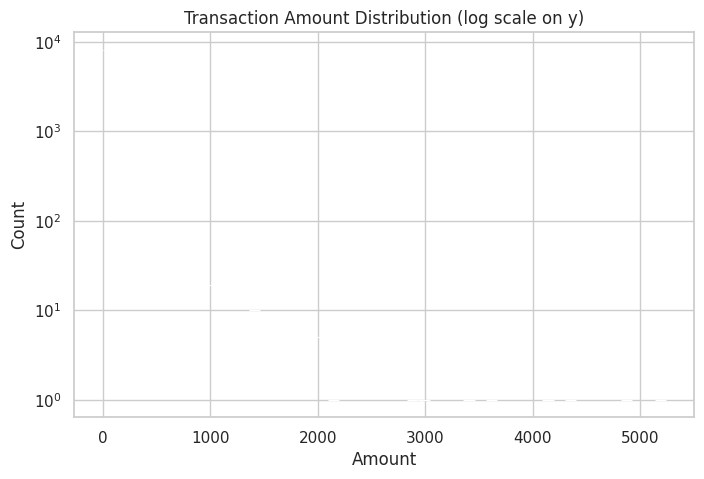

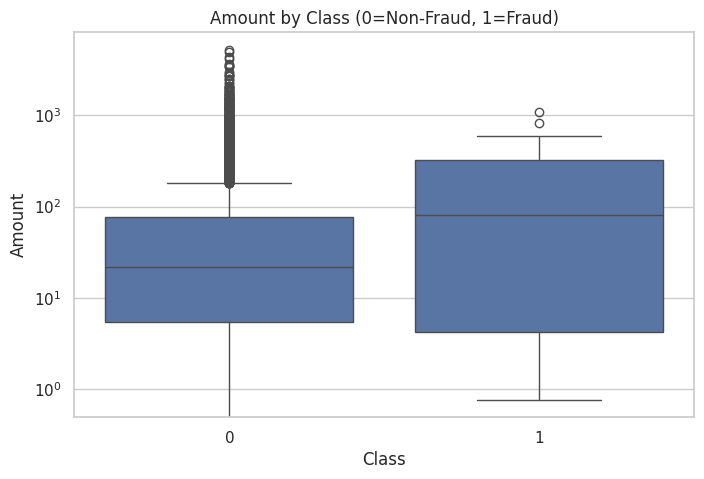

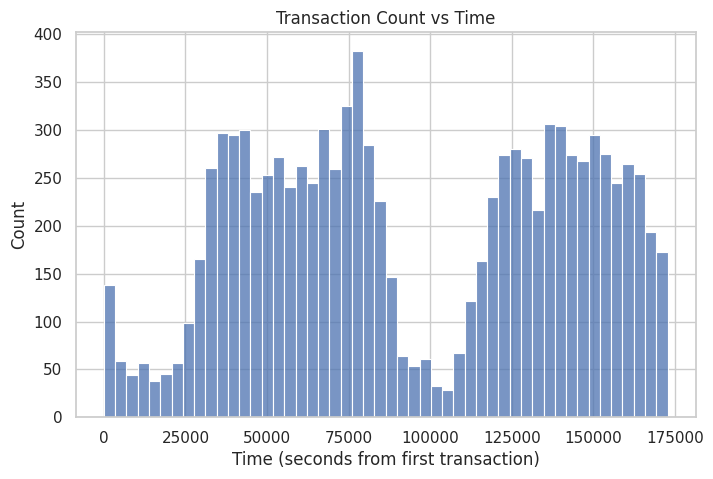

In [6]:
# Sample down for visualization to avoid huge plots
sample_df = df.sample(10000, random_state=42)

# Amount distribution
sns.histplot(sample_df['Amount'], bins=50, log_scale=(False, True))
plt.title("Transaction Amount Distribution (log scale on y)")
plt.show()

# Amount by class
sns.boxplot(x='Class', y='Amount', data=sample_df)
plt.yscale('log')
plt.title("Amount by Class (0=Non-Fraud, 1=Fraud)")
plt.show()

# Time vs transactions
sns.histplot(sample_df['Time'], bins=50)
plt.title("Transaction Count vs Time")
plt.xlabel("Time (seconds from first transaction)")
plt.show()

### EDA Interpretation (Finance / Payments)

From the plots:

- **Amount**: Fraudulent transactions may show different amount patterns
  (e.g., some higher-value attempts), but not all fraud is large; small
  test transactions also occur.
- **Time**: Fraud may cluster at certain times (night, off-peak hours),
  but here `Time` is simply seconds since the first transaction, not a
  direct hour-of-day feature.

In a real payments system, we'd engineer richer features:
- Hour of day, day of week, distance from cardholder's home, merchant
  category, country, and device fingerprints.
- This dataset is already PCA-transformed for confidentiality, but the
  modeling logic is similar.

In [7]:
# Features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling Approach: Logistic Regression

We use **logistic regression** as our baseline model:

- This is a **supervised binary classification** method.[web:29]
- It models the probability that a transaction is fraud (`Class=1`) given
  its features.
- Mathematically, it assumes the log-odds of fraud are a linear
  combination of the input features, and applies a sigmoid to map that
  to a probability between 0 and 1.[web:29]

Why it makes sense for card fraud:

- Many fraud vs non-fraud patterns can be approximated by a linear
  boundary in some transformed feature space (here PCA components plus
  amount and time).[web:20][web:29]
- The model outputs **probabilities**, which can be used like a risk
  score in a payments authorization engine.
- It is fast, relatively interpretable, and widely used as a baseline
  in fraud detection research and practice.[web:21][web:25][web:29]

We also handle **class imbalance** by using class weights so that
mistakes on fraud examples are penalized more heavily.

In [8]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # important for imbalance
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



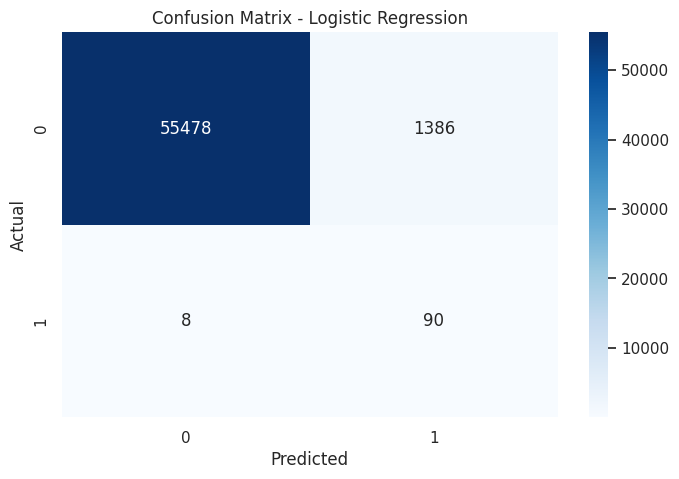

ROC-AUC: 0.9720834996210077


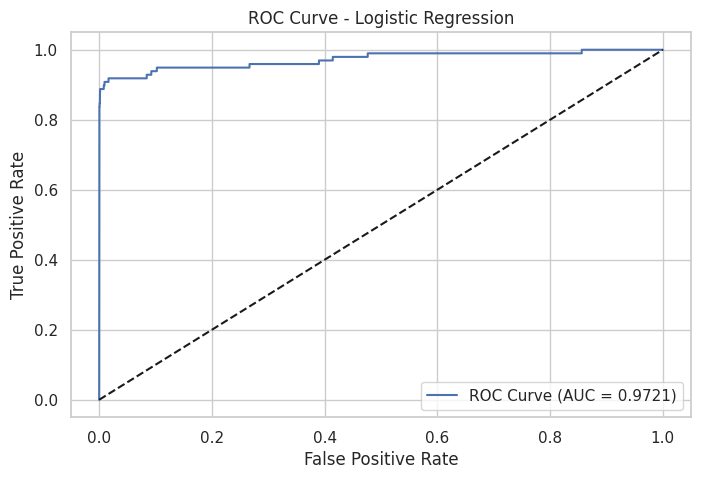

In [9]:
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### Metrics Interpretation (Payments Risk View)

Key metrics:

- **Recall (fraud class)**: Of all actual frauds, how many did we catch?
  High recall means fewer missed frauds (lower direct losses).
- **Precision (fraud class)**: Of all transactions we flagged as fraud,
  how many were truly fraudulent?
  High precision means fewer false alarms and less customer friction.
- **ROC-AUC**: Measures the model's ability to rank frauds above
  non-frauds across thresholds; closer to 1 is better.[web:20][web:29]

Payments trade-off:

- A bank can adjust the decision threshold on the predicted probability.
  - Higher threshold → fewer false positives, but more fraud slips
    through (lower recall).
  - Lower threshold → more fraud caught, but more legitimate transactions
    are blocked or challenged.

In real-time authorization, banks tune this threshold and sometimes use
different thresholds by merchant, country, or customer segment to
balance fraud losses vs customer experience.


Classification report at threshold=0.3:
              precision    recall  f1-score   support

           0     0.9999    0.9437    0.9710     56864
           1     0.0273    0.9184    0.0531        98

    accuracy                         0.9437     56962
   macro avg     0.5136    0.9310    0.5120     56962
weighted avg     0.9982    0.9437    0.9694     56962



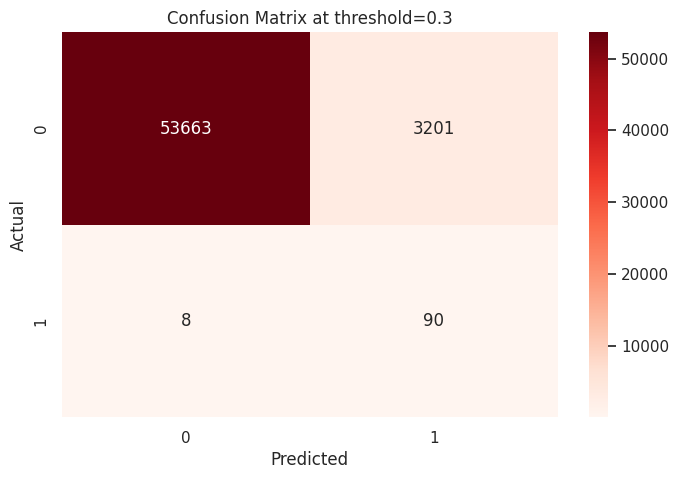

In [10]:
# Example: lower threshold to be more aggressive in catching fraud, to test how different values affect the fraud detection system

threshold = 0.3  # play with this
y_pred_thresh = (y_proba >= threshold).astype(int)

print(f"Classification report at threshold={threshold}:")
print(classification_report(y_test, y_pred_thresh, digits=4))

cm_thresh = confusion_matrix(y_test, y_pred_thresh)
sns.heatmap(cm_thresh, annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix at threshold={threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    class_weight='balanced_subsample',
    random_state=42
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

### Logistic Regression vs Random Forest

- **Logistic Regression**:
  - Linear model, easier to interpret.
  - Gives a straightforward probability score.
  - Good, fast baseline; widely used in risk modeling.

- **Random Forest**:
  - Ensemble of decision trees capturing nonlinear relationships and
    feature interactions.[web:22]
  - Often improves recall and ROC-AUC at the cost of interpretability
    and some extra training time.

In a bank's payments system:

- A team might start with logistic regression for interpretability and
  governance reasons, then move to tree-based ensembles once they can
  justify the complexity and validate performance gains.
  

## Limitations and Next Steps

Limitations:

- Features are anonymized (PCA components), so we can't directly
  interpret which real-world attributes matter most.
- We only use static features; real systems incorporate device IDs,
  customer history, merchant risk scores, and network signals.
- We train once on a static dataset; production systems monitor for
  model drift and retrain regularly.[web:22]

Possible extensions:

- Use more advanced models (e.g., XGBoost) and compare performance.
- Implement threshold tuning to optimize specific business metrics
  (e.g., maximize fraud dollars caught subject to a false positive limit).
- Wrap the model in an API (Flask / FastAPI) that scores incoming
  transactions, mimicking real-time authorization.